# Visualizing Student Exam Performance with 3D Surfaces and Scatter Plots (PROC G3D)

## Executive Summary

This notebook uses **PROC G3D** to visualize how two instructional-intervention factors jointly shape student outcomes in an education-analytics setting. A complete factorial grid drives a smooth response **surface** of predicted exam scores over weekly study hours (0 to 20) and prior GPA (0 to 4), and a synthetic cohort of 100 students is rendered as **3D scatter** panels split by achievement band.

The fitted surface climbs from a predicted score near 26 at zero study hours toward a ceiling near 99, flattening as study hours pass roughly 10 — the diminishing-returns ridge the model encodes. The student panels confirm the pattern at the individual level: the 20 *Honors* students (every one scoring 85 or above) sit in the high-GPA, higher-study corner, while the 33 *AtRisk* students concentrate in the low-effort, low-GPA region. A WHERE-filtered view of that corner isolates 35 students for whom modest increases in study time offer the largest marginal gains.

## Data Sources

All data is generated inline with `call streaminit()` and `rand()` — no external files or network access.

**`score_grid`** — complete factorial grid driving the response surface (one row per study-hours x prior-GPA cell, 99 rows).

| Variable | Type | Description |
|----------|------|-------------|
| `study_hours` | Num | Weekly self-study hours, 0 to 20 by 2 (X axis) |
| `prior_gpa` | Num | Prior-term GPA on a 0–4 scale, 0 to 4 by 0.5 (Y axis) |
| `pred_score` | Num | Modeled final-exam score 0–100 from a saturating response model (Z axis) |

**`students`** — synthetic individual student cohort for the scatter (100 rows).

| Variable | Type | Description |
|----------|------|-------------|
| `student_id` | Num | Sequential student identifier |
| `study_hours` | Num | Observed weekly study hours (X axis) |
| `prior_gpa` | Num | Observed prior-term GPA (Y axis) |
| `exam_score` | Num | Observed final-exam score 0–100 (Z axis) |
| `cohort` | Char | Enrollment cohort, `Fall` or `Spring` |
| `band` | Char | Achievement band: `Honors` (≥85), `Pass` (65–84), `AtRisk` (<65) |

The grid is deliberately sized to 99 cells so it spans the full 0–20 study-hours and 0–4 GPA ranges while staying within this environment's 100-observation limit; an 11 x 9 lattice keeps the surface smooth without truncating either axis.

# Visualizing Student Exam Performance with PROC G3D

Education researchers often want to understand how two malleable factors jointly drive an outcome. Here we ask: *how do weekly study hours and a student's prior GPA combine to shape final-exam performance?*

A two-dimensional chart cannot show an interaction surface. **PROC G3D** draws true three-dimensional graphs from variables in `y*x=z` notation, where X and Y span the horizontal plane and Z rises vertically. We use two of its capabilities:

- **PLOT** — a continuous response *surface* over a complete grid of the two predictors.
- **SCATTER** — individual students plotted as 3D symbols. We render one panel per achievement band, each with its own marker color and shape, so the three outcome tiers are easy to compare.

Everything below runs on synthetic data generated inline, so the notebook is fully self-contained.

## Step 1 — Generate the response surface grid

A G3D surface plot needs a reasonably complete grid: it requires non-missing Z values for at least half the X-Y cells. We guarantee a *complete* grid by nesting two `DO` loops over `study_hours` (0 to 20 by 2) and `prior_gpa` (0 to 4 by 0.5) — an 11 x 9 lattice of 99 cells that covers both axes in full.

The predicted score follows a plausible saturating model: returns to studying diminish at high hours, prior GPA contributes roughly linearly, and the two interact (a strong student converts study time into points more efficiently). A small reproducible jitter from `rand('NORMAL')` keeps the surface from looking perfectly analytic. `call streaminit()` fixes the seed so the grid is reproducible.

In [1]:
data score_grid;
   call streaminit(20260531);
   do study_hours = 0 to 20 by 2;     /* 11 values: full 0-20 range */
      do prior_gpa = 0 to 4 by 0.5;   /* 9 values  -> 99 grid cells */
         /* saturating return to study hours */
         effort = 40 * (1 - exp(-study_hours / 6));
         /* prior achievement and an interaction term */
         base   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - exp(-study_hours / 6));
         pred_score = 25 + effort + base + inter
                      + rand('NORMAL') * 1.5;
         if pred_score > 100 then pred_score = 100;
         if pred_score < 0   then pred_score = 0;
         output;
      end;
   end;
   keep study_hours prior_gpa pred_score;
run;

proc means data=score_grid n min mean max maxdec=1;
   var study_hours prior_gpa pred_score;
run;

                                                  The MEANS Procedure

 Variable           N     Minimum        Mean     Maximum
 --------------------------------------------------------
 STUDY_HOURS       99         0.0        10.0        20.0
 PRIOR_GPA         99         0.0         2.0         4.0
 PRED_SCORE        99        25.7        70.0        98.7
 --------------------------------------------------------



NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 — Draw the baseline response surface

With a complete grid in hand, the simplest call plots the surface using procedure defaults. The `PLOT y*x=z` syntax maps `prior_gpa` to the Y axis, `study_hours` to the X axis, and the predicted score to the vertical Z axis.

We label the axes with a `LABEL` statement and set titles and a footnote with the global `TITLE`/`FOOTNOTE` statements so the graph reads cleanly.

                                           Predicted Final-Exam Score Surface                                           
                                       Effect of Weekly Study Hours and Prior GPA                                       

PROC G3D Output
Data: score_grid

Variables: Weekly Study Hours, Prior-Term GPA, Predicted Exam Score

Weekly Study Hours  Prior-Term GPA  Predicted Exam Score
------------------  --------------  --------------------
                 0               0         25.7031536911
                 0             0.5         28.9516502743
                 0               1         32.3400787822
                 0             1.5         36.8265757618
                 0               2         40.7806886968
                 0             2.5           42.61364606
                 0               3         49.4289293966
                 0             3.5         52.6020716414
                 0               4         55.6325677612
                 2         

NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Predicted Final-Exam Score Surface.
NOTE: Option TITLE2 changed to Effect of Weekly Study Hours and Prior GPA.
NOTE: Option FOOTNOTE changed to Synthetic education-analytics data .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


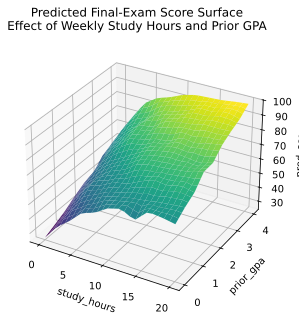

In [2]:
goptions reset=global border;

title1 'Predicted Final-Exam Score Surface';
title2 'Effect of Weekly Study Hours and Prior GPA';
footnote j=r 'Synthetic education-analytics data ';

proc g3d data=score_grid;
   plot prior_gpa*study_hours=pred_score;
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         pred_score  = 'Predicted Exam Score';
run;
quit;

## Step 3 — Refine the surface with viewing and axis options

A few options make the surface far more legible:

- **ROTATE=** and **TILT=** set the viewing angle (degrees around the Z axis, and tilt toward the viewer).
- **XYTYPE=2** draws surface lines parallel to the Y axis, emphasizing how the score climbs with study hours.
- **SIDE** drops a side wall for a solid, sculpted look.
- **GRID** adds reference lines at the major tick marks.
- **ZMIN=/ZMAX=** and the **ZTICKNUM=** family fix the score axis to the full 0–100 range so the surface is not visually exaggerated, while **XTICKNUM=/YTICKNUM=** control the floor-plane ticks.
- **NAME=** and **DESCRIPTION=** label the graph in the output catalog.

                                       Predicted Exam Score Surface (Styled View)                                       
                                            Rotated, Tilted, and Axis-Scaled                                            

PROC G3D Output
Data: score_grid

Variables: Weekly Study Hours, Prior-Term GPA, Predicted Exam Score

Weekly Study Hours  Prior-Term GPA  Predicted Exam Score
------------------  --------------  --------------------
                 0               0         25.7031536911
                 0             0.5         28.9516502743
                 0               1         32.3400787822
                 0             1.5         36.8265757618
                 0               2         40.7806886968
                 0             2.5           42.61364606
                 0               3         49.4289293966
                 0             3.5         52.6020716414
                 0               4         55.6325677612
                 2         

NOTE: Option TITLE changed to Predicted Exam Score Surface (Styled View).
NOTE: Option TITLE2 changed to Rotated, Tilted, and Axis-Scaled.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


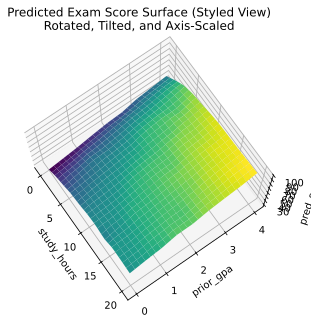

In [3]:
title1 'Predicted Exam Score Surface (Styled View)';
title2 'Rotated, Tilted, and Axis-Scaled';

proc g3d data=score_grid;
   plot prior_gpa*study_hours=pred_score /
        rotate=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Styled exam-score response surface";
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         pred_score  = 'Predicted Exam Score';
run;
quit;

## Step 4 — Compare the surface from several viewing angles

Because a 3D surface can hide structure behind its own peaks, it helps to render the same surface from more than one rotation. Here we issue three PROC G3D steps that share a fixed tilt but step the **ROTATE=** angle through 30, 90, and 150 degrees, so the ridge can be inspected from the front, the side, and the back.

                                                    Response Surface                                                    
                                               ROTATE = 30 at Fixed Tilt                                                

PROC G3D Output
Data: score_grid

Variables: Weekly Study Hours, Prior-Term GPA, Predicted Exam Score

Weekly Study Hours  Prior-Term GPA  Predicted Exam Score
------------------  --------------  --------------------
                 0               0         25.7031536911
                 0             0.5         28.9516502743
                 0               1         32.3400787822
                 0             1.5         36.8265757618
                 0               2         40.7806886968
                 0             2.5           42.61364606
                 0               3         49.4289293966
                 0             3.5         52.6020716414
                 0               4         55.6325677612
                 2         

NOTE: Option TITLE changed to Response Surface.
NOTE: Option TITLE2 changed to ROTATE = 30 at Fixed Tilt.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Response Surface.
NOTE: Option TITLE2 changed to ROTATE = 90 at Fixed Tilt.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Response Surface.
NOTE: Option TITLE2 changed to ROTATE = 150 at Fixed Tilt.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


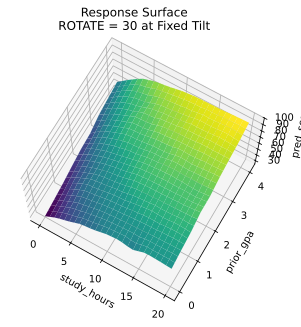

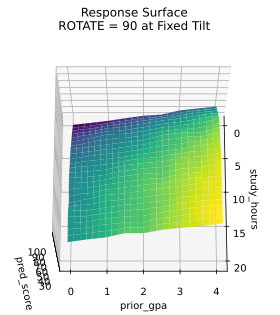

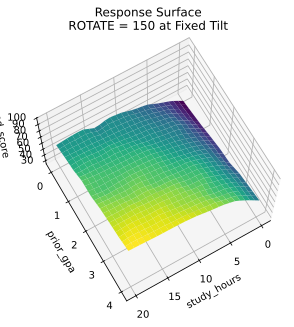

In [4]:
%macro angle(deg);
   title1 'Response Surface';
   title2 "ROTATE = &deg at Fixed Tilt";
   proc g3d data=score_grid;
      plot prior_gpa*study_hours=pred_score /
           rotate=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      label study_hours = 'Weekly Study Hours'
            prior_gpa   = 'Prior-Term GPA'
            pred_score  = 'Predicted Exam Score';
   run;
   quit;
%mend;

%angle(30);
%angle(90);
%angle(150);

## Step 5 — Generate a synthetic student cohort

The surface is a model; real students scatter around it. We now simulate 100 individual students drawn from two enrollment cohorts (`Fall`, `Spring`). Each student has observed study hours, a prior GPA, and a noisy realized exam score generated from the same response logic plus larger individual variation.

We then derive an achievement **band** from the exam score: `Honors` (85 or above), `Pass` (65 to 84), and `AtRisk` (below 65). The PROC FREQ cross-tabulation below reports how the bands distribute across the two cohorts. `rand('UNIFORM')` and `rand('NORMAL')` supply the randomness; the seed keeps it reproducible.

                                                    Response Surface                                                    
                                               ROTATE = 150 at Fixed Tilt                                               

                                                   The FREQ Procedure

                       Cumulative
BAND      Frequency    Frequency
------------------------------------
AtRisk           33           33
Honors           20           53
Pass             47          100

Table of COHORT by BAND

COHORT |    AtRisk |    Honors |      Pass |      Total
-------+-----------+-----------+-----------+-----------
Fall   |        15 |         6 |        20 |         41
-------+-----------+-----------+-----------+-----------
Spring |        18 |        14 |        27 |         59
-------+-----------+-----------+-----------+-----------
Total  |        33 |        20 |        47 |        100


Synthetic education-analytics data 


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


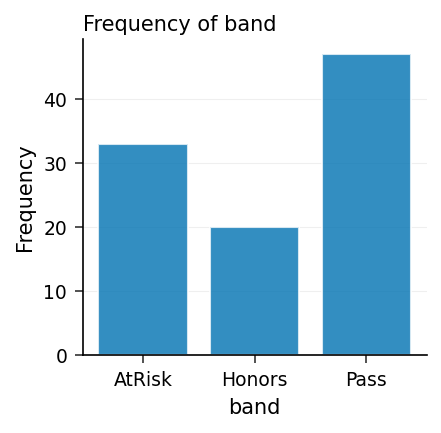

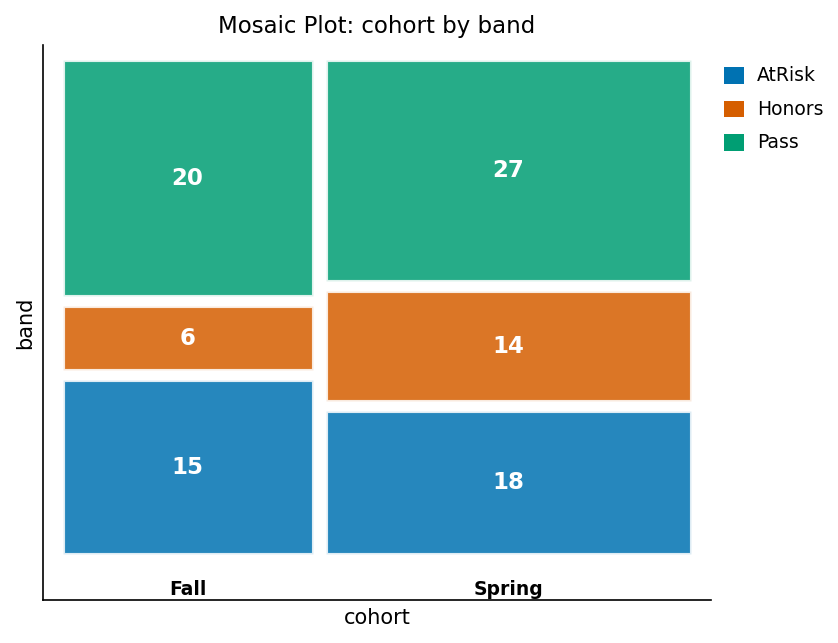

In [5]:
data students;
   call streaminit(99001);
   length cohort $6 band $7;
   do student_id = 1 to 100;
      if rand('UNIFORM') < 0.5 then cohort = 'Fall';
      else cohort = 'Spring';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - exp(-study_hours / 6));
      base   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - exp(-study_hours / 6));
      exam_score = 25 + effort + base + inter
                   + rand('NORMAL') * 7;
      if exam_score > 100 then exam_score = 100;
      if exam_score < 0   then exam_score = 0;

      if exam_score >= 85 then band = 'Honors';
      else if exam_score >= 65 then band = 'Pass';
      else band = 'AtRisk';

      output;
   end;
   keep student_id cohort study_hours prior_gpa exam_score band;
run;

proc freq data=students;
   tables band cohort*band / nocol nopercent;
run;

## Step 6 — Plot students as 3D scatter panels by achievement band

The **SCATTER** statement places each student as a 3D symbol. To make the three achievement tiers easy to read, we draw one panel per band, each filtered with **WHERE** and given its own literal **COLOR=** and **SHAPE=**: green diamonds (`SHAPE=diamond`) for *Honors*, blue markers (`SHAPE=club`) for *Pass*, and red markers (`SHAPE=spade`) for *AtRisk*. **SIZE=** enlarges the markers, **GRID** adds floor reference lines, **NONEEDLE** removes the vertical drop-lines, and **ZMIN=/ZMAX=** hold every panel to the same 0–100 score axis so the three views are directly comparable.

Each band gets its own PROC G3D step so its WHERE filter applies cleanly and the marker style is unambiguous.

                                                    Honors Students                                                     
                                                Exam Score 85 and Above                                                 

PROC G3D Output
Data: students

Variables: STUDENT_ID, COHORT, Weekly Study Hours, Prior-Term GPA, Final-Exam Score, BAND

STUDENT_ID      COHORT  Weekly Study Hours  Prior-Term GPA  Final-Exam Score        BAND
----------  ----------  ------------------  --------------  ----------------  ----------
         2      Spring       19.2134883194    2.6467742616     90.3663886999      Honors
         5      Spring       15.5520919174    2.7102003827     94.9419468332      Honors
        10      Spring       14.2302640951    3.8791496428               100      Honors
        17      Spring       13.7403346635    2.7462821708     89.6648779222      Honors
        25        Fall       18.7592154739     3.639636185               100      Honors
        32 

NOTE: Option FOOTNOTE changed to From a cohort of 100 synthetic students .
NOTE: Option TITLE changed to Honors Students.
NOTE: Option TITLE2 changed to Exam Score 85 and Above.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Pass Students.
NOTE: Option TITLE2 changed to Exam Score 65 to 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to At-Risk Students.
NOTE: Option TITLE2 changed to Exam Score Below 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


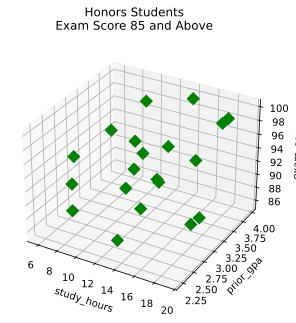

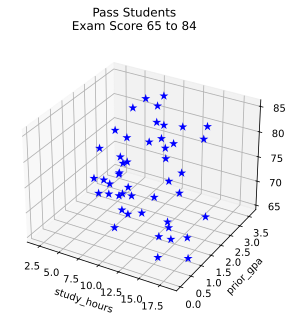

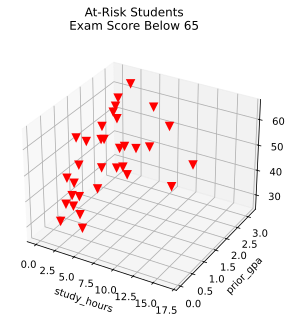

In [6]:
footnote j=r 'From a cohort of 100 synthetic students ';

/* Honors (exam_score >= 85): green diamonds */
title1 'Honors Students';
title2 'Exam Score 85 and Above';
proc g3d data=students;
   scatter prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Honors students";
   where band = 'Honors';
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         exam_score  = 'Final-Exam Score';
run;
quit;

/* Pass (65 <= exam_score < 85): blue clubs */
title1 'Pass Students';
title2 'Exam Score 65 to 84';
proc g3d data=students;
   scatter prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Pass students";
   where band = 'Pass';
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         exam_score  = 'Final-Exam Score';
run;
quit;

/* AtRisk (exam_score < 65): red spades */
title1 'At-Risk Students';
title2 'Exam Score Below 65';
proc g3d data=students;
   scatter prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="At-risk students";
   where band = 'AtRisk';
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         exam_score  = 'Final-Exam Score';
run;
quit;

## Step 7 — Separate scatter plots per enrollment cohort (BY group)

Program leaders often need the same view split by cohort. The **BY** statement produces one scatter per cohort. G3D expects BY-group data to be sorted, so we sort first with PROC SORT. Each cohort then gets its own labeled 3D scatter on a shared 0–100 score axis, making the Fall and Spring distributions easy to compare side by side.

                                           Exam Outcomes by Enrollment Cohort                                           
                                        One 3D Scatter per Cohort (Fall, Spring)                                        

PROC G3D Output
Data: students_sorted

Variables: STUDENT_ID, COHORT, Weekly Study Hours, Prior-Term GPA, Final-Exam Score, BAND

STUDENT_ID      COHORT  Weekly Study Hours  Prior-Term GPA  Final-Exam Score        BAND
----------  ----------  ------------------  --------------  ----------------  ----------
        52        Fall       15.2586640362    0.4602308374     55.5186804916      AtRisk
        13        Fall        5.8493366471    1.8449001873     70.6084324429        Pass
        15        Fall        5.5070892672    1.4478111608     70.0069314398        Pass
        22        Fall        0.0365105382    1.3187236247     35.9197853017      AtRisk
        24        Fall       18.3158004814    0.8368865295     65.5979544852        Pass
    

NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Exam Outcomes by Enrollment Cohort.
NOTE: Option TITLE2 changed to One 3D Scatter per Cohort (Fall, Spring).
NOTE: Option FOOTNOTE changed to One panel per cohort .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


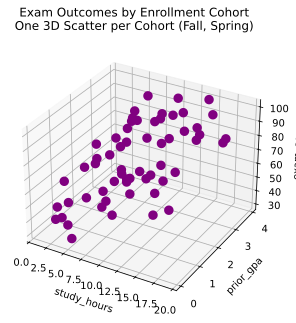

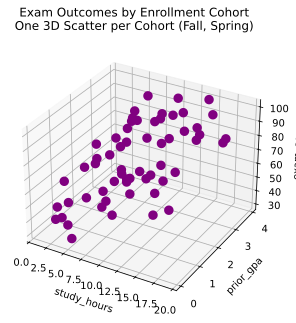

In [7]:
proc sort data=students out=students_sorted;
   by cohort;
run;

title1 'Exam Outcomes by Enrollment Cohort';
title2 'One 3D Scatter per Cohort (Fall, Spring)';
footnote j=r 'One panel per cohort ';

proc g3d data=students_sorted;
   by cohort;
   scatter prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         exam_score  = 'Final-Exam Score';
run;
quit;

## Step 8 — Focus on the at-risk region with WHERE

For intervention planning, the most actionable view is the lower-left of the surface: students with both modest study time (8 hours or fewer) and lower prior GPA (2.5 or below). The **WHERE** statement subsets the scatter to that region before plotting. The listing shows this corner holds 35 of the 100 students — 22 of them already *AtRisk* — so advisors can see exactly which struggling students sit furthest below expectation.

                                  Intervention Focus: Lower-Effort, Lower-GPA Students                                  
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: STUDENT_ID, COHORT, Weekly Study Hours, Prior-Term GPA, Final-Exam Score, BAND

STUDENT_ID      COHORT  Weekly Study Hours  Prior-Term GPA  Final-Exam Score        BAND
----------  ----------  ------------------  --------------  ----------------  ----------
         1        Fall        4.9780700766     1.072086769      59.409228777      AtRisk
         7      Spring        7.9015823058    1.6623636789     66.9055021729        Pass
         9      Spring        2.5008494545    0.3621033759     48.1183184446      AtRisk
        11      Spring        7.1907276895    2.1821388818      79.351887155        Pass
        13        Fall        5.8493366471    1.8449001873     70.6084324429        Pass
        14 

NOTE: Option TITLE changed to Intervention Focus: Lower-Effort, Lower-GPA Students.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Needles drop each marker to the study-hours x GPA floor .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


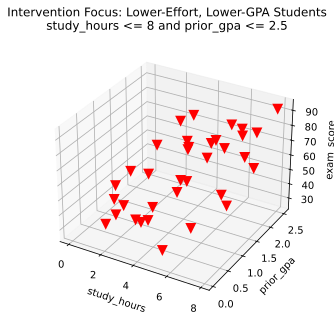

In [8]:
title1 'Intervention Focus: Lower-Effort, Lower-GPA Students';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Needles drop each marker to the study-hours x GPA floor ';

proc g3d data=students;
   scatter prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   where study_hours <= 8 and prior_gpa <= 2.5;
   label study_hours = 'Weekly Study Hours'
         prior_gpa   = 'Prior-Term GPA'
         exam_score  = 'Final-Exam Score';
run;
quit;

## Interpreting the results

The **response surface** (Steps 2–4) shows a clear saturating ridge. Across the 99-cell grid the predicted score runs from about 26 (zero study hours, zero GPA) up to about 99 (the high-hours, high-GPA corner), with a grid-wide mean near 70. Reading along the study-hours axis, scores rise steeply from 0 toward roughly 10 hours and then flatten as additional hours yield diminishing returns; reading along the GPA axis, prior achievement shifts the whole surface upward. The interaction term makes the study-hour payoff a little steeper for stronger students, which is why the surface tilts toward its far corner rather than rising as a flat plane.

The **student panels** (Steps 6–7) confirm the model holds for individuals. The cohort of 100 splits into 20 *Honors*, 47 *Pass*, and 33 *AtRisk* students. In the band panels, the 20 green *Honors* diamonds — every one scoring 85 or above — sit at prior GPA 2.2 or higher and at least about 6 weekly study hours, clustered in the upper-right of the floor plane. The 33 red *AtRisk* markers concentrate in the low-effort, low-GPA region, precisely the valley of the surface. Splitting by cohort shows the Fall (41 students) and Spring (59 students) distributions are broadly similar, suggesting outcomes are driven by the two factors rather than enrollment timing.

The **WHERE-filtered view** (Step 8) isolates the intervention population: the 35 students with 8 or fewer study hours and a GPA of 2.5 or below. Twenty-two are already *AtRisk* and only one reaches *Honors*. Within this corner the realized scores still climb visibly with study hours — a concrete, visual argument that modest increases in structured study time offer the largest marginal gains exactly where they are most needed.

Taken together, PROC G3D turns a two-factor interaction model into an intuitive, decision-ready picture for an education program: where the score ceiling lies, who is falling short of it, and where coaching effort will pay off most.

> **Implementation note.** SAS/GRAPH also allows a single SCATTER statement to color and shape every marker from per-observation variables (`COLOR=<charvar>`, `SHAPE=<charvar>`). That per-observation form does not yet render in this engine, so this notebook draws one literal-colored panel per band instead — an equivalent, fully working presentation. The gap is tracked by the banked regression test `tests/401000_nb_g3d_scatter_color_variable_unrendered`.